# Feasible-route method comparison

Compare the candidate route legs for one shipment under the configured cost-weighted seed union and a count-matched, distance-only path set. Change `K` or `SHIPMENT_ID` below, then run all cells.

In [38]:
from pathlib import Path
import sys

# Set SHIPMENT_ID to a listed ID to select it explicitly. None uses the first ID.
K = 5
SHIPMENT_ID = None

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'src').is_dir() and (REPO_ROOT.parent / 'src').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'src').is_dir():
    raise RuntimeError('Run this notebook from the repository root or notebooks directory.')

sys.path.insert(0, str(REPO_ROOT / 'src'))
CONFIG_PATH = REPO_ROOT / 'src' / 'sensitivity_config.json'


In [39]:
from main import (
    ProblemPreparer,
    SensitivityConfig,
    _distance_paths_with_matching_counts,
)
from stoc_optimod import build_seed_union_paths_by_shipment

if not isinstance(K, int) or isinstance(K, bool) or K <= 0:
    raise ValueError('K must be a positive integer.')

config = SensitivityConfig(CONFIG_PATH)
network = ProblemPreparer(config).prepare_network()
shipment_ids = sorted(network.shipments)
if not shipment_ids:
    raise ValueError('The prepared network contains no shipments.')

if SHIPMENT_ID is None:
    shipment_id = shipment_ids[0]
elif SHIPMENT_ID not in network.shipments:
    raise ValueError(
        f'Unknown SHIPMENT_ID {SHIPMENT_ID!r}. Available shipment IDs: ' +
        ', '.join(shipment_ids)
    )
else:
    shipment_id = SHIPMENT_ID

shipment = network.shipments[shipment_id]
print(f'Selected shipment: {shipment_id} (K={K})')
print(f'Origin: {shipment.origin.node_id}; destination: {shipment.destination.node_id}')
print('Available shipment IDs:')
print(', '.join(shipment_ids))


C:\Users\micah\OneDrive - Umich\humanitarian-multimodal\src\data_processing.py:83: UserWarning: Temporarily removed unique_carrier due to naming misalignment
  warnings.warn("Temporarily removed unique_carrier due to naming misalignment")
C:\Users\micah\OneDrive - Umich\humanitarian-multimodal\src\data_processing.py:83: UserWarning: Temporarily removed unique_carrier due to naming misalignment
  warnings.warn("Temporarily removed unique_carrier due to naming misalignment")
C:\Users\micah\OneDrive - Umich\humanitarian-multimodal\src\data_processing.py:278: UserWarning: Unknown airport codes found. Unknown Origins: ['DUESSELDORF', 'yyz'], Unknown Destinations: ['AYGR, PNP', 'Aden', 'NAN/Tonga', 'OUAGADOUGOU']. Rows with these codes will be dropped.
  warnings.warn(
C:\Users\micah\OneDrive - Umich\humanitarian-multimodal\src\data_processing.py:83: UserWarning: Temporarily removed unique_carrier due to naming misalignment
  warnings.warn("Temporarily removed unique_carrier due to naming mi

Selected shipment: 22-0237 (K=5)
Origin: NP115_ORD_O; destination: NP115_MUC_D
Available shipment IDs:
22-0237, 22-0302, 22-0303, 22-0305, 22-0323, 22-0335, 22-0337, 22-0347, 22-0350, 22-0352, 22-0358, 22-0463, 23-0006, 23-0010, 23-0020, 23-0060, 23-0086, 23-0101, 23-0113, 23-0114, 23-0115, 23-0124, 23-0126-1, 23-0126-10, 23-0126-11, 23-0126-12, 23-0126-13, 23-0126-14, 23-0126-15, 23-0126-16, 23-0126-17, 23-0126-18, 23-0126-19, 23-0126-2, 23-0126-20, 23-0126-21, 23-0126-22, 23-0126-23, 23-0126-24, 23-0126-25, 23-0126-26, 23-0126-27, 23-0126-28, 23-0126-29, 23-0126-3, 23-0126-30, 23-0126-31, 23-0126-32, 23-0126-33, 23-0126-34, 23-0126-35, 23-0126-36, 23-0126-37, 23-0126-38, 23-0126-39, 23-0126-4, 23-0126-40, 23-0126-41, 23-0126-42, 23-0126-43, 23-0126-44, 23-0126-5, 23-0126-6, 23-0126-7, 23-0126-8, 23-0126-9, 23-0145, 23-0147, 23-0151, 23-0177, 23-0191, 23-0200, 23-0247, 23-0250, 23-0251, 23-0280, 23-0364, 23-0388, 23-0391, 24-0156, 24-0187, 24-0227, 24-0228, 24-0229, 24-0230, 24-0238, 

In [40]:
selected_shipments = {shipment_id: shipment}
cost_paths = build_seed_union_paths_by_shipment(
    selected_shipments,
    network.legs,
    cost_seed_pairs=config.cost_seed_pairs(),
    max_paths=K,
)[shipment_id]

# Match the distance-only path count to this shipment's unique seed-union paths.
distance_paths = _distance_paths_with_matching_counts(
    selected_shipments,
    network.legs,
    {shipment_id: len(cost_paths)},
)[shipment_id]

def unique_legs(paths):
    return tuple(dict.fromkeys(route for path in paths for route in path))

cost_legs = set(unique_legs(cost_paths))
distance_legs = set(unique_legs(distance_paths))
cost_only_legs = cost_legs - distance_legs
distance_only_legs = distance_legs - cost_legs
shared_legs = cost_legs & distance_legs

print('Candidate-set summary')
print(f'  Cost-weighted seed union: {len(cost_paths)} paths, {len(cost_legs)} unique legs')
print(f'  Distance-only (count matched): {len(distance_paths)} paths, {len(distance_legs)} unique legs')
print(f'  Cost-weighted only: {len(cost_only_legs)} legs')
print(f'  Distance-only only: {len(distance_only_legs)} legs')
print(f'  Shared: {len(shared_legs)} legs')


Candidate-set summary
  Cost-weighted seed union: 21 paths, 41 unique legs
  Distance-only (count matched): 21 paths, 25 unique legs
  Cost-weighted only: 18 legs
  Distance-only only: 2 legs
  Shared: 23 legs


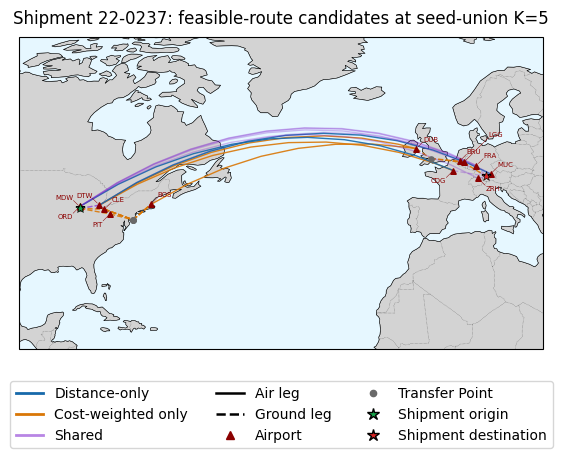

In [41]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.transforms import Bbox

COLORS = {
    'distance-only': '#1769aa',
    'cost-weighted only': '#d97706',
    'shared': '#7e22ce',
}
# Match a full-width Elsevier figure at its final LaTeX size so the
# point sizes below are not reduced by a large \\includegraphics scaling factor.
FIGURE_WIDTH_INCHES = 6.5
MIN_TEXT_SIZE_PT = 10
plt.rcParams.update({'font.size': MIN_TEXT_SIZE_PT})

def membership(route):
    if route in shared_legs:
        return 'shared'
    if route in cost_only_legs:
        return 'cost-weighted only'
    return 'distance-only'

def set_route_extent(axis, routes):
    nodes = {node_id for route in routes for node_id in route[:2]}
    longitudes = [network.nodes[node_id].longitude for node_id in nodes]
    latitudes = [network.nodes[node_id].latitude for node_id in nodes]
    longitude_span = max(longitudes) - min(longitudes)
    latitude_span = max(latitudes) - min(latitudes)
    if longitude_span > 180:
        axis.set_global()
        return
    longitude_padding = max(5.0, longitude_span * 0.08)
    latitude_padding = max(25.0, latitude_span * 1.5)
    axis.set_extent((
        max(-180.0, min(longitudes) - longitude_padding),
        min(180.0, max(longitudes) + longitude_padding),
        max(-85.0, min(latitudes) - latitude_padding),
        min(85.0, max(latitudes) + latitude_padding),
    ), crs=ccrs.PlateCarree())

all_legs = cost_legs | distance_legs
fig = plt.figure(figsize=(FIGURE_WIDTH_INCHES, 4.8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=-20))
ax.add_feature(cfeature.LAND.with_scale('110m'), facecolor='lightgray', edgecolor='black', linewidth=0.35)
ax.add_feature(cfeature.OCEAN.with_scale('110m'), facecolor='#e6f7ff')
ax.add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth=0.4)
ax.add_feature(cfeature.BORDERS.with_scale('110m'), linestyle=':', linewidth=0.35, alpha=0.6)

for route in sorted(all_legs):
    leg = network.legs[route]
    ax.plot(
        [leg.origin.longitude, leg.destination.longitude],
        [leg.origin.latitude, leg.destination.latitude],
        color=COLORS[membership(route)],
        linestyle='--' if route[2] == 'ground' else '-',
        linewidth=1,
        alpha=0.3 if membership(route) == 'shared' else 0.9,
        transform=ccrs.Geodetic(),
        zorder=3,
    )

route_node_ids = sorted({node_id for route in all_legs for node_id in route[:2]})
endpoint_node_ids = {shipment.origin.node_id, shipment.destination.node_id}
airport_label_nodes = [
    network.nodes[node_id] for node_id in route_node_ids
    if network.nodes[node_id].connection_type == 'air'
]
# Each node receives only its highest-precedence symbol: OD star, then airport, then transfer point.
airport_nodes = [node for node in airport_label_nodes if node.node_id not in endpoint_node_ids]
ground_nodes = [network.nodes[node_id] for node_id in route_node_ids if network.nodes[node_id].connection_type != 'air']
transfer_nodes = [
    node for node in ground_nodes
    if node.node_id not in endpoint_node_ids
]

if transfer_nodes:
    ax.scatter([node.longitude for node in transfer_nodes], [node.latitude for node in transfer_nodes],
               color='dimgray', s=14, transform=ccrs.PlateCarree(), zorder=5)
if airport_nodes:
    ax.scatter([node.longitude for node in airport_nodes], [node.latitude for node in airport_nodes],
               marker='^', color='darkred', s=15, transform=ccrs.PlateCarree(), zorder=5)
ax.scatter(shipment.origin.longitude, shipment.origin.latitude, marker='*', s=50,
           color='#16a34a', edgecolor='black', linewidth=0.45, transform=ccrs.PlateCarree(), zorder=7)
ax.scatter(shipment.destination.longitude, shipment.destination.latitude, marker='*', s=50,
           color='#dc2626', edgecolor='black', linewidth=0.45, transform=ccrs.PlateCarree(), zorder=7)

set_route_extent(ax, all_legs)

# Place each airport label at the closest available offset.  The display-space
# collision check protects all map symbols and labels already placed.
airport_transform = ccrs.PlateCarree()._as_mpl_transform(ax)
label_offsets = (
    (5, 5), (5, -5), (-5, 5), (-5, -5), (8, 0), (-8, 0), (0, 8), (0, -8),
    (10, 10), (10, -10), (-10, 10), (-10, -10), (14, 0), (-14, 0),
)
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
icon_boxes = []
for node_id in route_node_ids:
    node_x, node_y = airport_transform.transform((network.nodes[node_id].longitude, network.nodes[node_id].latitude))
    icon_boxes.append(Bbox.from_bounds(node_x - 6, node_y - 6, 12, 12))
occupied_label_boxes = []
for node in airport_label_nodes:
    chosen = None
    for offset_x, offset_y in label_offsets:
        label = ax.annotate(
            node.node_id, (node.longitude, node.latitude), xycoords=airport_transform,
            xytext=(offset_x, offset_y), textcoords='offset points',
            fontsize=5, color='darkred',
            ha='left' if offset_x >= 0 else 'right',
            va='bottom' if offset_y >= 0 else 'top', zorder=6,
        )
        fig.canvas.draw()
        label_box = label.get_window_extent(renderer)
        if not any(label_box.overlaps(box) for box in (*icon_boxes, *occupied_label_boxes)):
            chosen = (label, offset_x, offset_y, label_box)
            break
        label.remove()
    if chosen is None:
        # A dense airport cluster can exhaust the close candidates; retain a readable fallback.
        offset_x, offset_y = 18, 18
        label = ax.annotate(
            node.node_id, (node.longitude, node.latitude), xycoords=airport_transform,
            xytext=(offset_x, offset_y), textcoords='offset points',
            fontsize=5, color='darkred', ha='left', va='bottom', zorder=6,
        )
        fig.canvas.draw()
        chosen = (label, offset_x, offset_y, label.get_window_extent(renderer))
    label, offset_x, offset_y, label_box = chosen
    ax.annotate(
        '', (node.longitude, node.latitude), xycoords=airport_transform,
        xytext=(offset_x, offset_y), textcoords='offset points',
        arrowprops={'arrowstyle': '-', 'color': 'darkred', 'lw': 0.35, 'shrinkA': 0, 'shrinkB': 2},
        zorder=5.5,
    )
    occupied_label_boxes.append(label_box.expanded(1.08, 1.18))

ax.set_title(f'Shipment {shipment_id}: feasible-route candidates at seed-union K={K}', fontsize=12, pad=10)
ax.legend(handles=[
    Line2D([0], [0], color=COLORS['distance-only'], lw=2, label='Distance-only'),
    Line2D([0], [0], color=COLORS['cost-weighted only'], lw=2, label='Cost-weighted only'),
    Line2D([0], [0], color=COLORS['shared'], lw=2, alpha=0.55, label='Shared'),
    Line2D([0], [0], color='black', lw=1.8, linestyle='-', label='Air leg'),
    Line2D([0], [0], color='black', lw=1.8, linestyle='--', label='Ground leg'),
    Line2D([0], [0], color='darkred', marker='^', linestyle='None', markersize=5.5, label='Airport'),
    Line2D([0], [0], color='dimgray', marker='o', linestyle='None', markersize=4.5, label='Transfer Point'),
    Line2D([0], [0], color='#16a34a', marker='*', markeredgecolor='black', linestyle='None', markersize=9, label='Shipment origin'),
    Line2D([0], [0], color='#dc2626', marker='*', markeredgecolor='black', linestyle='None', markersize=9, label='Shipment destination'),
], loc='upper center', bbox_to_anchor=(0.5, -0.08), ncols=3, frameon=True, fontsize=MIN_TEXT_SIZE_PT)
fig.subplots_adjust(bottom=0.24, top=0.89, left=0.02, right=0.98)
plt.savefig(REPO_ROOT / 'output' / 'figures' / f'feasible-route-candidates-{shipment_id}-K{K}.pdf', dpi=300, bbox_inches='tight')
# plt.show()
